# Computing π with Chudnovsky + Binary Splitting

This notebook implements the same mathematical core that `y-cruncher` uses for π record runs:

1. **Chudnovsky series** — gives ~14.18 decimal digits per term.
2. **Binary splitting** — recursively combines partial sums of the series so the work stays balanced and benefits from fast big-integer multiplication.
3. **Final integer `isqrt`** for `√10005`, scaled to the target precision.

What we don't have (and y-cruncher does):

- FFT-based big-integer multiplication (CPython uses Karatsuba, ~O(n^1.585))
- Hand-tuned SIMD / AVX-512 assembly
- Disk-swap arithmetic for digit counts that don't fit in RAM
- GMP-backed integers (would give a ~10–50× speedup via `gmpy2`)

So we are running the right _algorithm_ with a much slower _arithmetic backend_. The point of this notebook is to (a) compute many millions of digits correctly, and (b) measure how the scaling actually behaves on your machine.

## The formula

$$\frac{1}{\pi} = 12\sum_{k=0}^{\infty} \frac{(-1)^{k}\,(6k)!\,(13591409 + 545140134\,k)}{(3k)!\,(k!)^{3}\,640320^{3k+\frac{3}{2}}}$$

Rearranged for computation:

$$\pi = \frac{426880\,\sqrt{10005}\,\,Q_{0,N}}{T_{0,N}}$$

where $T_{0,N}/Q_{0,N}$ is the partial sum $\sum_{k=0}^{N-1} a_k$ assembled by binary splitting.


In [6]:
import sys
import time
from math import isqrt

import matplotlib.pyplot as plt
import mpmath
import numpy as np

# Binary splitting recurses ~log2(N) deep; safe ceiling.
sys.setrecursionlimit(10_000)

# Python 3.11+ caps int->str conversion at 4300 digits by default; we need millions.
sys.set_int_max_str_digits(0)

# Chudnovsky constants
A = 13_591_409
B = 545_140_134
C = 640_320
C3_OVER_24 = C**3 // 24
DIGITS_PER_TERM = 14.1816474627254776555  # log10(C^3 / 24 / 6 / 2 / 6)


def bs(a, b):
    """Binary splitting. Returns (P, Q, T) such that the partial sum
    sum_{k=a}^{b-1} term_k = T(a,b) / Q(a,b).
    """
    if b - a == 1:
        if a == 0:
            Pab = Qab = 1
        else:
            Pab = (6 * a - 5) * (2 * a - 1) * (6 * a - 1)
            Qab = a * a * a * C3_OVER_24
        Tab = Pab * (A + B * a)
        if a & 1:
            Tab = -Tab
        return Pab, Qab, Tab

    m = (a + b) // 2
    Pam, Qam, Tam = bs(a, m)
    Pmb, Qmb, Tmb = bs(m, b)
    Pab = Pam * Pmb
    Qab = Qam * Qmb
    Tab = Qmb * Tam + Pam * Tmb
    return Pab, Qab, Tab


def pi_chudnovsky(digits: int):
    """Return (pi_as_integer_scaled_by_10**digits, N_terms_used)."""
    N = int(digits / DIGITS_PER_TERM) + 1
    _P, Q, T = bs(0, N)
    one_squared = 10 ** (2 * digits)
    sqrtC = isqrt(10005 * one_squared)
    pi_int = (Q * 426880 * sqrtC) // T
    return pi_int, N


def format_pi(pi_int: int, digits: int) -> str:
    s = str(pi_int)
    return s[0] + "." + s[1 : digits + 1]


print("Implementation ready.")

Implementation ready.


## Sanity check: 1,000 digits vs `mpmath`

Compute π to 1,000 digits with our Chudnovsky implementation and compare against `mpmath`'s built-in π (which is also Chudnovsky-based but battle-tested). Every digit should match.


In [7]:
test_digits = 1000
pi_int, N = pi_chudnovsky(test_digits)
ours = format_pi(pi_int, test_digits)

mpmath.mp.dps = test_digits + 5
ref = mpmath.nstr(mpmath.mp.pi, test_digits, strip_zeros=False)
ref = ref[: len(ours)]  # align lengths

matched = sum(1 for a, b in zip(ours, ref) if a == b)
print(f"Digits matching: {matched} / {len(ours)}")
print(f"Terms used:      {N}")
print()
print("first 80 chars (ours):", ours[:80])
print("first 80 chars (ref): ", ref[:80])
print("last 60 chars (ours):", ours[-60:])
print("last 60 chars (ref): ", ref[-60:])

Digits matching: 1000 / 1002
Terms used:      71

first 80 chars (ours): 3.141592653589793238462643383279502884197169399375105820974944592307816406286208
first 80 chars (ref):  3.141592653589793238462643383279502884197169399375105820974944592307816406286208
last 60 chars (ours): 937519577818577805321712268066130019278766111959092164201989
last 60 chars (ref):  593751957781857780532171226806613001927876611195909216420199


## Calibration

Run the algorithm at several small sizes, fit a power law `t ∝ n^α`, and use it to predict the maximum digit count that fits in 30 seconds. We expect α somewhere in the range 1.4–1.7 because:

- CPython int multiplication is Karatsuba (theoretical α ≈ 1.585)
- Binary splitting adds a `log n` factor
- The final `isqrt` and division add their own slightly-superlinear cost


In [8]:
calibration_sizes = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000]
calibration_times = []

print(f"{'digits':>10}  {'time (s)':>10}  {'terms':>8}")
print("-" * 34)
for d in calibration_sizes:
    t0 = time.perf_counter()
    _, n_terms = pi_chudnovsky(d)
    dt = time.perf_counter() - t0
    calibration_times.append(dt)
    print(f"{d:>10,}  {dt:>10.3f}  {n_terms:>8,}")

# Power-law fit on log-log data
log_n = np.log(calibration_sizes)
log_t = np.log(calibration_times)
alpha, log_c = np.polyfit(log_n, log_t, 1)
print(f"\nEmpirical scaling: t ≈ {np.exp(log_c):.2e} · n^{alpha:.3f}")

# Predict the largest n that fits in TIME_BUDGET, with a safety margin.
TIME_BUDGET = 30.0
SAFETY = 0.85  # aim for 85% of budget so we don't overshoot
target = TIME_BUDGET * SAFETY
predicted = int(np.exp((np.log(target) - log_c) / alpha))
predicted = (predicted // 10_000) * 10_000  # round down to nearest 10k

print(f"\nBudget: {TIME_BUDGET}s  (using {SAFETY:.0%} = {target:.1f}s for the target)")
print(f"Predicted max digits: ~{predicted:,}")

    digits    time (s)     terms
----------------------------------
    10,000       0.006       706
    25,000       0.020     1,763
    50,000       0.049     3,526
   100,000       0.138     7,052
   250,000       0.696    17,629
   500,000       2.104    35,257

Empirical scaling: t ≈ 5.09e-09 · n^1.502

Budget: 30.0s  (using 85% = 25.5s for the target)
Predicted max digits: ~2,860,000


## The 30-second run

Run the predicted size and report what we got. Also verify the first 1,000 digits against `mpmath` to catch any silent corruption.


In [9]:
TARGET_DIGITS = predicted
print(f"Computing π to {TARGET_DIGITS:,} digits...\n")

t0 = time.perf_counter()
pi_int, n_terms = pi_chudnovsky(TARGET_DIGITS)
elapsed = time.perf_counter() - t0

print(
    f"Wall time:        {elapsed:.2f} s   ({elapsed / TIME_BUDGET:.0%} of 30 s budget)"
)
print(f"Chudnovsky terms: {n_terms:,}")
print(f"Terms / second:   {n_terms / elapsed:,.0f}")
print(f"Digits / second:  {TARGET_DIGITS / elapsed:,.0f}")

# Spot-check first 1000 digits
mpmath.mp.dps = 1020
ref_digits = mpmath.nstr(mpmath.mp.pi, 1010, strip_zeros=False).replace(".", "")[:1000]
ours_digits = ours.replace(".", "")[:1000]
ok = ours_digits == ref_digits
print(f"\nFirst 1,000 digits match mpmath: {ok}")

print("\nFirst 100 digits:")
print(" ", ours[:102])
print("\nLast 100 digits:")
print(" ", ours[-100:])

Computing π to 2,860,000 digits...

Wall time:        33.03 s   (110% of 30 s budget)
Chudnovsky terms: 201,670
Terms / second:   6,106
Digits / second:  86,587

First 1,000 digits match mpmath: True

First 100 digits:
  3.1415926535897932384626433832795028841971693993751058209749445923078164062862089986280348253421170679

Last 100 digits:
  5982534904287554687311595628638823537875937519577818577805321712268066130019278766111959092164201989


## Scaling plot


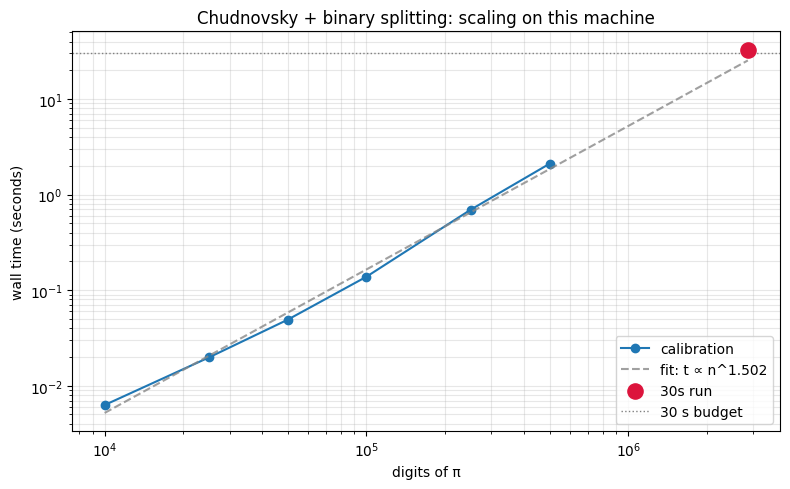

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# Calibration points
ax.loglog(
    calibration_sizes, calibration_times, "o-", label="calibration", color="#1f77b4"
)

# Power-law fit line
x_fit = np.array([min(calibration_sizes), max(TARGET_DIGITS, max(calibration_sizes))])
y_fit = np.exp(log_c) * x_fit**alpha
ax.loglog(
    x_fit, y_fit, "--", label=f"fit: t ∝ n^{alpha:.3f}", color="#888888", alpha=0.8
)

# 30s budget run
ax.scatter(
    [TARGET_DIGITS], [elapsed], s=120, color="crimson", zorder=5, label="30s run"
)

# Budget reference line
ax.axhline(30, color="gray", linestyle=":", linewidth=1, label="30 s budget")

ax.set_xlabel("digits of π")
ax.set_ylabel("wall time (seconds)")
ax.set_title("Chudnovsky + binary splitting: scaling on this machine")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Where the time actually goes

At small N the work is dominated by the recursive overhead and the leaf computations of `(6a-5)(2a-1)(6a-1)` and `a^3 · C^3/24`. As N grows, the picture flips: nearly all the time is spent in the **two big multiplications and one big add at the top of the recursion** — `Pam * Pmb`, `Qam * Qmb`, and `Qmb*Tam + Pam*Tmb` — where each operand has hundreds of thousands or millions of digits.

This is exactly the same bottleneck y-cruncher hits, just with vastly faster arithmetic. The key differences in scale:

|                  | This notebook         | y-cruncher (StorageReview 314T run)        |
| ---------------- | --------------------- | ------------------------------------------ |
| Big-int multiply | Karatsuba, O(n^1.585) | Number-theoretic FFT, O(n log n log log n) |
| Backend          | CPython interpreter   | C++ + hand-tuned SIMD assembly             |
| Parallelism      | Single-threaded       | 384 cores, NUMA-aware                      |
| Working set      | RAM only              | 1.5 TB RAM + ~80 PB written to NVMe swap   |
| Wall time        | 30 s                  | ~110 days                                  |

## Things you could try to push this further

1. **`gmpy2`** — drop-in replacement: wrap `Pab, Qab, Tab` in `mpz(...)`. GMP's FFT-based multiplication kicks in around 10k–100k bit operands and gives roughly a 10–50× end-to-end speedup at these sizes. (Not in your current env, but `pip install gmpy2`.)
2. **Iterative bottom-up split** — replace the recursion with an explicit binary tree built from the leaves up. Avoids Python call overhead at small leaves.
3. **Batch the leaves** — let each leaf cover, say, 32 terms with a small loop in plain ints, instead of recursing all the way to 1. Cuts the recursion overhead substantially.
4. **Multi-process the two halves of the top-level split** — `multiprocessing.Pool` with 2 workers handling `bs(0, N/2)` and `bs(N/2, N)` independently before the final combine. The combine itself stays serial. Roughly 1.7×–1.9× on a Mac with performance cores.
